In [ ]:
!pip install evaluate seqeval transformers==4.45.2 sentence-transformers==3.1.1 xformers trl peft accelerate bitsandbytes torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ALL PARAMS
max_length = 2048

dtype = None
# NOTE TO SELF: A lower LLM temperature value (close to 0) produces more deterministic and focused outputs, ideal for tasks requiring factual accuracy, such as summarization or translation.
#  NOTE TO SELF: min_p is 0.1 as we need strictly structured text with minimal variation
temperature = 0.5
min_p = 0.1

mount_path="/content/drive"
path=mount_path+"/My Drive/unmasked-exp/"

!mkdir -p "$path"

def pathTo(to):
  return path+to
save_model_path = pathTo('final')

In [ ]:
import json
import sys
import numpy as np
import evaluate
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer
from transformers import DataCollatorForTokenClassification
import transformers
from transformers import AutoTokenizer





In [ ]:
seqeval = evaluate.load("seqeval")


In [ ]:
#
# with open('/content/drive/MyDrive/Colab Notebooks/CVNER/train.json', 'r') as file:
#     training_json = json.load(file)

import pandas as pd




all_possible_labels = set()
def load_set(name):
  global all_possible_labels
  training_json = pd.read_json(path_or_buf=pathTo(name), lines=True).to_dict(orient='records')
  ret = []
  for i in range(len(training_json)):
    element = training_json[i]

    text = element['text']
    labels = element['labels']
    text = text.replace('\\n','  ')
    text = text.replace('\n',' ')
    # print(text)
    newText=""
    lastEnd = 0
    # Order labels by starting index
    labels = sorted(labels, key=lambda x: x[0])



    parts = []
    partsEntities =[]

    for label in labels:
      start = label[0]
      end = label[1]
      label_name = label[2]
      all_possible_labels.add(label_name)
      ###########################################
      # Split to Parts where each part is the whole sentence or entity
      ###########################################
      # parts.extend([text[lastEnd:start],text[start:end]])
      # partsEntities.extend(['O',label_name])

      ###########################################
      # Split to parts where each part is a word
      ###########################################

      textPart = text[lastEnd:start]
      textParts = textPart.split(' ')
      textParts = list(filter(lambda x:x!='',textParts))
      parts.extend(textParts)
      partsEntities.extend(['O']*len(textParts))

      textPart = text[start:end]
      textParts = textPart.split(' ')
      textParts = list(filter(lambda x:x!='', textParts))
      parts.extend(textParts)
      partsEntities.extend([label_name]*len(textParts))




      # newText+=text[lastEnd:start]+"<"+label_name+">"+text[start:end]+"</"+label_name+">"
      lastEnd = end
    ret.append({'tokens':parts,'ner_tags':partsEntities})
  return ret


def load_dataset():
  ret = {}
  for split_name in ['train', 'test']:
      data = load_set(split_name+'.json')
      ret[split_name] = Dataset.from_list(data)

  return DatasetDict(ret)

dataset = load_dataset()

In [ ]:
print(dataset['test'][11]['ner_tags'])

['Name', 'Name', 'Designation', 'Designation', 'O', 'Companies worked at', 'Location', 'Location', 'O', 'O', 'O', 'O', 'Email Address', 'Email Address', 'Email Address', 'O', 'Designation', 'Designation', 'O', 'O', 'Years of Experience', 'Years of Experience', 'O', 'O', 'O', 'Job Specific Skills', 'Job Specific Skills', 'Job Specific Skills', 'O', 'O', 'Tech Tools', 'O', 'Tech Tools', 'O', 'Job Specific Skills', 'O', 'O', 'Tech Tools', 'O', 'Tech Tools', 'Tech Tools', 'O', 'O', 'O', 'O', 'O', 'Tech Tools', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'Designation', 'Designation', 'O', 'O', 'O', 'O', 'Job Specific Skills', 'Job Specific Skills', 'O', 'O', 'O', 'Job Specific Skills', 'Job Specific Skills', 'O', 'O', 'O', 'O', 'Job Specific Skills', 'Job Specific Skills', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'Tech Tools', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'Tech Tools', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O

In [ ]:
# Print all emails in dataset['test]
for i in range(len(dataset['train'])):
  if(i!=11):
    continue
  el = dataset['train'][i]
  for j, tag in enumerate(el['ner_tags']):
    if(tag == 'Email Address'):
      print(i, el['tokens'][j], tag)



11 indeed.com/r/Manjari-Singh/fd072d33991401f0 Email Address


In [ ]:
label_list = list(all_possible_labels)
label_list.append('O')
label2id = {v: k for k, v in enumerate(label_list)}
id2label = {k: v for k, v in enumerate(label_list)}


print(id2label)
print(label2id)
print(all_possible_labels)



{0: 'Designation', 1: 'Companies worked at', 2: 'Name', 3: 'Years of Experience', 4: 'Soft Skills', 5: 'Email Address', 6: 'Graduation Year', 7: 'Degree', 8: 'Tech Tools', 9: 'Location', 10: 'Job Specific Skills', 11: 'College Name', 12: 'O'}
{'Designation': 0, 'Companies worked at': 1, 'Name': 2, 'Years of Experience': 3, 'Soft Skills': 4, 'Email Address': 5, 'Graduation Year': 6, 'Degree': 7, 'Tech Tools': 8, 'Location': 9, 'Job Specific Skills': 10, 'College Name': 11, 'O': 12}
{'Designation', 'Companies worked at', 'Name', 'Years of Experience', 'Soft Skills', 'Email Address', 'Graduation Year', 'Degree', 'Tech Tools', 'Location', 'Job Specific Skills', 'College Name'}


In [ ]:
# model_id = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"
# model_id = "decapoda-research/llama-7b-hf"
# model_id = "QuantFactory/Meta-Llama-3-8B-GGUF"
# model_id = "meta-llama/Llama-3.1-8B"


model_id = pathTo("llama-3.1-8B-4bit")
print(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)

/content/drive/My Drive/unmasked-exp/llama-3.1-8B-4bit


In [ ]:
tokenizer.pad_token = tokenizer.eos_token
def tokenize_and_align_labels(examples):
      tokenized_inputs = tokenizer(examples["tokens"], is_split_into_words=True, padding='longest', max_length=max_length, truncation=True)

      labels = []
      for i, label in enumerate(examples[f"ner_tags"]):
          word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
          previous_word_idx = None
          label_ids = []
          for word_idx in word_ids:  # Set the special tokens to -100.
              if word_idx is None:
                  label_ids.append(-100)
              elif word_idx != previous_word_idx:  # Only label the first token of a given word.
                  # Get Id from label
                  # label_id = label2id[]
                  # print(word_idx, label[word_idx])
                  id = label2id[label[word_idx]]
                  label_ids.append(id)
              else:
                  label_ids.append(-100)
              previous_word_idx = word_idx
          labels.append(label_ids)

      tokenized_inputs["labels"] = labels
      return tokenized_inputs



# tokenized_ds = ds.map(tokenize_and_align_labels, batched=True)
# data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

tokenized_ds = dataset.map(tokenize_and_align_labels, batched=True)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

Map:   0%|          | 0/545 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_ds)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 545
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 50
    })
})


In [ ]:
# Iterate over each sequence of tokens in the dataset
lengths = {}
for seq_idx, token_sequence in enumerate(tokenized_ds['train']["tokens"]):
    print(f"Sequence {seq_idx}: Length: {len(token_sequence)}")
    lengths[seq_idx] = len(token_sequence)

# Print sorted
sorted_lengths = dict(sorted(lengths.items(), key=lambda item: item[1]))
for key, value in sorted_lengths.items():
    print(f"{key}: {value}")

Sequence 0: Length: 329
Sequence 1: Length: 267
Sequence 2: Length: 223
Sequence 3: Length: 199
Sequence 4: Length: 514
Sequence 5: Length: 153
Sequence 6: Length: 1165
Sequence 7: Length: 519
Sequence 8: Length: 767
Sequence 9: Length: 572
Sequence 10: Length: 949
Sequence 11: Length: 1087
Sequence 12: Length: 444
Sequence 13: Length: 347
Sequence 14: Length: 355
Sequence 15: Length: 95
Sequence 16: Length: 492
Sequence 17: Length: 546
Sequence 18: Length: 431
Sequence 19: Length: 563
Sequence 20: Length: 421
Sequence 21: Length: 196
Sequence 22: Length: 2132
Sequence 23: Length: 561
Sequence 24: Length: 481
Sequence 25: Length: 689
Sequence 26: Length: 1444
Sequence 27: Length: 1401
Sequence 28: Length: 325
Sequence 29: Length: 609
Sequence 30: Length: 804
Sequence 31: Length: 645
Sequence 32: Length: 977
Sequence 33: Length: 974
Sequence 34: Length: 500
Sequence 35: Length: 477
Sequence 36: Length: 752
Sequence 37: Length: 513
Sequence 38: Length: 275
Sequence 39: Length: 770
Sequen

In [ ]:
print(tokenized_ds['train'][0])
# Print all keys in that
print(tokenized_ds['train'].features.keys())

{'tokens': ['Kavitha', 'K', 'Senior', 'System', 'Engineer', '-', 'Infosys', 'Limited', 'Salem,', 'Tamil', 'Nadu', '-', 'Email', 'me', 'on', 'Indeed:', 'indeed.com/r/Kavitha-K/8977ce8ce48bc800', 'Seeking', 'to', 'work', 'with', 'a', 'software', 'firm,', 'to', 'constantly', 'upgrade', 'my', 'knowledge', 'and', 'utilize', 'my', 'existing', 'skills', 'to', 'benefit', 'the', 'concerned', 'organization', 'WORK', 'EXPERIENCE', 'Senior', 'System', 'Engineer', 'Infosys', 'Limited', '-', 'December', '2014', 'to', 'Present', 'Unix,', 'CA7', 'scheduler', 'Infosys', 'Limited', '-', 'December', '2015', 'to', 'February', '2018', 'Qlikview', 'Level', '1', '•', 'Basic', 'knowledge', 'of', 'creating', 'simple', 'dashboards', 'with', 'different', 'Production', 'support', 'style', 'using', 'Qlikview', 'components', 'like', 'List', 'Box,', 'Slider,', 'Buttons,', 'charts', 'and', 'Bookmarks.', '•', 'Created', 'different', 'types', 'of', 'sheet', 'objects', 'like', 'List', 'boxes,', 'Buttons,', 'Multi', 'box

In [ ]:
# -*- coding: utf-8 -*-
# Code adapted from https://github.com/salesforce/LAVIS & LLaMA NERs
from copy import deepcopy

from transformers.models.llama.modeling_llama import *
from transformers.modeling_outputs import TokenClassifierOutput




# Copied from transformers.models.bart.modeling_bart._make_causal_mask
def _make_causal_mask(
    input_ids_shape, dtype, device, past_key_values_length: int = 0
):
    """
    Make causal mask used for bi-directional self-attention.
    """
    bsz, tgt_len = input_ids_shape
    mask = torch.full((tgt_len, tgt_len), torch.finfo(dtype).min, device=device)
    mask_cond = torch.arange(mask.size(-1), device=device)
    mask.masked_fill_(mask_cond < (mask_cond + 1).view(mask.size(-1), 1), 0)
    mask = mask.to(dtype)

    if past_key_values_length > 0:
        mask = torch.cat([torch.zeros(tgt_len, past_key_values_length, dtype=dtype, device=device), mask], dim=-1)
    return mask[None, None, :, :].expand(bsz, 1, tgt_len, tgt_len + past_key_values_length)



# Copied from transformers.models.bart.modeling_bart._expand_mask
def _expand_mask(mask, dtype, tgt_len = None):
    """
    Expands attention_mask from `[bsz, seq_len]` to `[bsz, 1, tgt_seq_len, src_seq_len]`.
    """
    bsz, src_len = mask.size()
    tgt_len = tgt_len if tgt_len is not None else src_len

    expanded_mask = mask[:, None, None, :].expand(bsz, 1, tgt_len, src_len).to(dtype)

    inverted_mask = 1.0 - expanded_mask

    return inverted_mask.masked_fill(inverted_mask.to(torch.bool), torch.finfo(dtype).min)


class UnmaskingLlamaModel(LlamaPreTrainedModel):

    def __init__(self, config):
        super().__init__(config)
        self.padding_idx = config.pad_token_id
        self.vocab_size = config.vocab_size

        self.embed_tokens = nn.Embedding(config.vocab_size, config.hidden_size, self.padding_idx)
        self.layers = nn.ModuleList([LlamaDecoderLayer(config, _) for _ in range(config.num_hidden_layers)])
        self.norm = LlamaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

        self.gradient_checkpointing = False
        # Initialize weights and apply final processing
        self.post_init()

    def get_input_embeddings(self):
        return self.embed_tokens

    def set_input_embeddings(self, value):
        self.embed_tokens = value

    # Copied from transformers.models.bart.modeling_bart.BartDecoder._prepare_decoder_attention_mask
    def _prepare_decoder_attention_mask(self, attention_mask, input_shape, inputs_embeds, past_key_values_length):
        # create causal mask
        # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
        combined_attention_mask = None
        if input_shape[-1] > 1:
            combined_attention_mask = _make_causal_mask(
                input_shape,
                inputs_embeds.dtype,
                device=inputs_embeds.device,
                past_key_values_length=past_key_values_length,
            )
        if attention_mask is not None:
            # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
            expanded_attn_mask = _expand_mask(attention_mask, inputs_embeds.dtype, tgt_len=input_shape[-1]).to(
                inputs_embeds.device
            )
            combined_attention_mask = (
                expanded_attn_mask if combined_attention_mask is None else expanded_attn_mask + combined_attention_mask
            )

        return combined_attention_mask

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        position_ids=None,
        past_key_values=None,
        inputs_embeds=None,
        use_cache=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
    ):
        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        use_cache = use_cache if use_cache is not None else self.config.use_cache

        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # retrieve input_ids and inputs_embeds
        if input_ids is not None and inputs_embeds is not None:
            raise ValueError("You cannot specify both decoder_input_ids and decoder_inputs_embeds at the same time")
        elif input_ids is not None:
            batch_size, seq_length = input_ids.shape
        elif inputs_embeds is not None:
            batch_size, seq_length, _ = inputs_embeds.shape
        else:
            raise ValueError("You have to specify either decoder_input_ids or decoder_inputs_embeds")

        seq_length_with_past = seq_length
        past_key_values_length = 0

        if past_key_values is not None:
            past_key_values_length = past_key_values[0][0].shape[2]
            seq_length_with_past = seq_length_with_past + past_key_values_length

        if position_ids is None:
            device = input_ids.device if input_ids is not None else inputs_embeds.device
            position_ids = torch.arange(
                past_key_values_length, seq_length + past_key_values_length, dtype=torch.long, device=device
            )
            position_ids = position_ids.unsqueeze(0).view(-1, seq_length)
        else:
            position_ids = position_ids.view(-1, seq_length).long()

        if inputs_embeds is None:
            inputs_embeds = self.embed_tokens(input_ids)
        # embed positions
        if attention_mask is None:
            attention_mask = torch.ones(
                (batch_size, seq_length_with_past), dtype=torch.bool, device=inputs_embeds.device
            )
        # causal mask
        '''
        attention_mask = self._prepare_decoder_attention_mask(
            attention_mask, (batch_size, seq_length), inputs_embeds, past_key_values_length
        )
        print('unmasking attention mask:')
        print(attention_mask)
        '''
        # remove causal mask
        attention_mask = torch.zeros(
            (batch_size, 1, seq_length, seq_length), device=inputs_embeds.device
        )

        hidden_states = inputs_embeds

        if self.gradient_checkpointing and self.training:
            if use_cache:
                logger.warning_once(
                    "`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`..."
                )
                use_cache = False

        # decoder layers
        all_hidden_states = () if output_hidden_states else None
        all_self_attns = () if output_attentions else None
        next_decoder_cache = () if use_cache else None

        for idx, decoder_layer in enumerate(self.layers):
            if output_hidden_states:
                all_hidden_states += (hidden_states,)

            past_key_value = past_key_values[idx] if past_key_values is not None else None

            if self.gradient_checkpointing and self.training:

                def create_custom_forward(module):
                    def custom_forward(*inputs):
                        # None for past_key_value
                        return module(*inputs, past_key_value, output_attentions)

                    return custom_forward

                layer_outputs = torch.utils.checkpoint.checkpoint(
                    create_custom_forward(decoder_layer),
                    hidden_states,
                    attention_mask,
                    position_ids,
                )
            else:
                layer_outputs = decoder_layer(
                    hidden_states,
                    attention_mask=attention_mask,
                    position_ids=position_ids,
                    past_key_value=past_key_value,
                    output_attentions=output_attentions,
                    use_cache=use_cache,
                )

            hidden_states = layer_outputs[0]

            if use_cache:
                next_decoder_cache += (layer_outputs[2 if output_attentions else 1],)

            if output_attentions:
                all_self_attns += (layer_outputs[1],)

        hidden_states = self.norm(hidden_states)

        # add hidden states from the last decoder layer
        if output_hidden_states:
            all_hidden_states += (hidden_states,)

        next_cache = next_decoder_cache if use_cache else None
        if not return_dict:
            return tuple(v for v in [hidden_states, next_cache, all_hidden_states, all_self_attns] if v is not None)
        return BaseModelOutputWithPast(
            last_hidden_state=hidden_states,
            past_key_values=next_cache,
            hidden_states=all_hidden_states,
            attentions=all_self_attns,
        )



class UnmaskingLlamaForTokenClassification(LlamaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.model = UnmaskingLlamaModel(config)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

        # Initialize weights and apply final processing
        self.post_init()

    def get_input_embeddings(self):
        return self.model.embed_tokens

    def set_input_embeddings(self, value):
        self.model.embed_tokens = value

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        position_ids=None,
        past_key_values=None,
        inputs_embeds=None,
        labels=None,
        use_cache=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
    ):
        r"""
        labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
            Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
            config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
            `config.num_labels > 1` a classification loss is computed (Cross-Entropy).
        """
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        outputs = self.model(
            input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_values=past_key_values,
            inputs_embeds=inputs_embeds,
            use_cache=use_cache,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        sequence_output = outputs[0]

        sequence_output = self.dropout(sequence_output)
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            loss_fct = CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return TokenClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )




In [ ]:
import torch
import torch.nn as nn
from transformers.models.llama.modeling_llama import LlamaDecoderLayer,LlamaRMSNorm
from peft import get_peft_model, LoraConfig, TaskType
from transformers import BitsAndBytesConfig, AutoModelForCausalLM


lora_r = 12

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_storage=torch.bfloat16,
)


model = UnmaskingLlamaForTokenClassification.from_pretrained(
    model_id, num_labels=len(label2id), id2label=id2label, label2id=label2id,
    quantization_config=quantization_config,
    torch_dtype=torch.bfloat16,

).bfloat16()


Unused kwargs: ['_load_in_4bit', '_load_in_8bit', 'quant_method']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.
/usr/local/lib/python3.10/dist-packages/transformers/quantizers/auto.py:182: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)
`low_cpu_mem_usage` was None, now set to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of UnmaskingLlamaForTokenClassification were not initialized from the model checkpoint at /content/drive/My Drive/unmasked-exp/llama-3.1-8B-4bit and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:

from peft import get_peft_model, LoraConfig, TaskType
lora_r = 12

peft_config = LoraConfig(task_type=TaskType.TOKEN_CLS, inference_mode=False, r=lora_r, lora_alpha=32, lora_dropout=0.1)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 5,165,069 || all params: 7,510,143,002 || trainable%: 0.0688


In [ ]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [ ]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


In [ ]:
from transformers import TrainingArguments, Trainer
# import is_bfloat16_supported


# from unsloth import is_bfloat16_supported
is_bfloat16_supported = True


epochs = 1
batch_size = 2
learning_rate = 5e-5
lora_r = 12



training_args = TrainingArguments(
    output_dir="my_awesome_ds_model-final-final",
    learning_rate=learning_rate,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=1,
    num_train_epochs=epochs,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
            fp16 = not is_bfloat16_supported,
        bf16 = is_bfloat16_supported,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)



/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.232492,0.729105,0.682658,0.705118,0.930761


/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Name seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Designation seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Location seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Email Address seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Years of Experience seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqev

TrainOutput(global_step=273, training_loss=0.18165736495356857, metrics={'train_runtime': 296.5875, 'train_samples_per_second': 1.838, 'train_steps_per_second': 0.92, 'total_flos': 4.677696924266496e+16, 'train_loss': 0.18165736495356857, 'epoch': 1.0})

In [ ]:
# Save Model to path
trainer.save_model(pathTo('my_awesome_ds_model-final-final-final-best'))

In [ ]:
# --- Run predictions on the test dataset ---
results = trainer.predict(tokenized_ds["test"])
predictions, label_ids, metrics = results.predictions, results.label_ids, results.metrics

# Convert raw logits to label indices.
predictions = np.argmax(predictions, axis=2)

# Decode predictions and true labels to their string representations.
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label_seq) if l != -100]
    for prediction, label_seq in zip(predictions, label_ids)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label_seq) if l != -100]
    for prediction, label_seq in zip(predictions, label_ids)
]

# Print overall evaluation metrics
print("\nTest Evaluation Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")



/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Name seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Designation seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Location seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Email Address seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Years of Experience seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.10/dist-packages/seqev


Test Evaluation Metrics:
test_loss: 0.2325
test_precision: 0.7291
test_recall: 0.6827
test_f1: 0.7051
test_accuracy: 0.9308
test_runtime: 12.9267
test_samples_per_second: 3.8680
test_steps_per_second: 3.8680




```
Before extending max_length:
Test Evaluation Metrics:
test_loss: 0.2483
test_precision: 0.6681
test_recall: 0.6923
test_f1: 0.6800
test_accuracy: 0.9182
test_runtime: 2.7690
test_samples_per_second: 18.0570
test_steps_per_second: 2.5280

After Extending max_length:
test_loss: 0.2222
test_precision: 0.7371
test_recall: 0.7035
test_f1: 0.7199
test_accuracy: 0.9323
test_runtime: 10.7508
test_samples_per_second: 4.6510
test_steps_per_second: 2.3250


After Extending max_length 20 epochs:
Train:
Test Evaluation Metrics:
test_loss: 0.0645
test_precision: 0.8603
test_recall: 0.8663
test_f1: 0.8633
test_accuracy: 0.9763
test_runtime: 122.6254
test_samples_per_second: 4.4440
test_steps_per_second: 2.2260

Test:
test_loss: 0.3263
test_precision: 0.7289
test_recall: 0.6650
test_f1: 0.6955
test_accuracy: 0.9264
test_runtime: 10.7205
test_samples_per_second: 4.6640
test_steps_per_second: 2.3320




After one go 20 epochs:
Test Evaluation Metrics:
test_loss: 0.2562
test_precision: 0.7249
test_recall: 0.6414
test_f1: 0.6806
test_accuracy: 0.9225
test_runtime: 10.8974
test_samples_per_second: 4.5880
test_steps_per_second: 2.2940
```



In [ ]:
# --- Analyze Incorrect Findings per Label ---

from collections import defaultdict

# Initialize dictionaries to hold false positives and false negatives for each label.
false_positives = defaultdict(list)
false_negatives = defaultdict(list)

# Assume that the test dataset contains the original token texts under the "tokens" field.
# Adjust this if your dataset uses a different key.
test_tokens = tokenized_ds["test"]["tokens"]

# Iterate over each test example.
for example_idx, (pred_seq, true_seq, tokens) in enumerate(zip(true_predictions, true_labels, test_tokens)):
    for token_idx, (pred_label, true_label, token) in enumerate(zip(pred_seq, true_seq, tokens)):
        if pred_label != true_label:
            # Record a false positive for the predicted label.
            false_positives[pred_label].append({
                "example_index": example_idx,
                "token_index": token_idx,
                "token": token,
                "true_label": true_label
            })
            # Record a false negative for the true label.
            false_negatives[true_label].append({
                "example_index": example_idx,
                "token_index": token_idx,
                "token": token,
                "predicted_label": pred_label
            })

# For each label, print the incorrect findings along with false positives and false negatives.
print("\nDetailed Error Analysis per Label:")
for label in label_list:
    if label == 'O':
      continue
    if label !='Email Address':
      continue
    print(f"\n=== Label: {label} ===")

    # Incorrect findings are the union of false positives and false negatives for this label.
    fp = false_positives.get(label, [])
    fn = false_negatives.get(label, [])

    print(f"\nFalse Positives for '{label}' (predicted as {label} but true label different) [{len(fp)}]:")
    if fp:
        for error in fp:
            print(f"  - Ex {error['example_index']} Token {error['token_index']}: '{error['token']}' "
                  f"(predicted: {label}, true: {error['true_label']})")
    else:
        print("  None.")

    print(f"\nFalse Negatives for '{label}' (true label is {label} but predicted differently) [{len(fn)}]:")
    if fn:
        for error in fn:
            print(f"  - Ex {error['example_index']} Token {error['token_index']}: '{error['token']}' "
                  f"(true: {label}, predicted: {error['predicted_label']})")
    else:
        print("  None.")




Detailed Error Analysis per Label:

=== Label: Email Address ===

False Positives for 'Email Address' (predicted as Email Address but true label different) [10]:
  - Ex 38 Token 63: 'ga' (predicted: Email Address, true: Location)
  - Ex 38 Token 64: 'r' (predicted: Email Address, true: Location)
  - Ex 38 Token 65: 'o' (predicted: Email Address, true: Location)
  - Ex 38 Token 66: 'f' (predicted: Email Address, true: Location)
  - Ex 38 Token 67: 'm' (predicted: Email Address, true: Location)
  - Ex 38 Token 69: 'm' (predicted: Email Address, true: Location)
  - Ex 38 Token 70: 'm' (predicted: Email Address, true: Location)
  - Ex 38 Token 71: 'm.' (predicted: Email Address, true: Location)
  - Ex 38 Token 72: 'ca' (predicted: Email Address, true: Location)
  - Ex 39 Token 14: 'ROSANNA' (predicted: Email Address, true: Name)

False Negatives for 'Email Address' (true label is Email Address but predicted differently) [5]:
  - Ex 5 Token 9: 'Indeed:' (true: Email Address, predicted: O)


In [ ]:
# Print accuracy per element in test dataset
print("\nAccuracy per Element in Test Dataset:")
for example_idx, (pred_seq, true_seq) in enumerate(zip(true_predictions, true_labels)):
    correct_count = sum(1 for pred, true in zip(pred_seq, true_seq) if pred == true and true !='O')
    total_count = len(pred_seq) - sum(1 for true in true_seq if true == 'O')
    accuracy = correct_count / total_count
    print(f"Example {example_idx + 1}: Accuracy = {accuracy:.4f}: Length = {len(dataset['train'][example_idx]['tokens'])}")


Accuracy per Element in Test Dataset:
Example 1: Accuracy = 0.9014: Length = 329
Example 2: Accuracy = 0.8639: Length = 267
Example 3: Accuracy = 0.9083: Length = 223
Example 4: Accuracy = 0.8333: Length = 199
Example 5: Accuracy = 0.7063: Length = 514
Example 6: Accuracy = 0.7843: Length = 153
Example 7: Accuracy = 0.5840: Length = 1165
Example 8: Accuracy = 0.6962: Length = 519
Example 9: Accuracy = 0.8315: Length = 767
Example 10: Accuracy = 0.7126: Length = 572
Example 11: Accuracy = 0.8083: Length = 949
Example 12: Accuracy = 0.8439: Length = 1087
Example 13: Accuracy = 0.5650: Length = 444
Example 14: Accuracy = 0.6667: Length = 347
Example 15: Accuracy = 0.6290: Length = 355
Example 16: Accuracy = 0.6100: Length = 95
Example 17: Accuracy = 0.8842: Length = 492
Example 18: Accuracy = 0.8387: Length = 546
Example 19: Accuracy = 0.6667: Length = 431
Example 20: Accuracy = 0.7327: Length = 563
Example 21: Accuracy = 0.7885: Length = 421
Example 22: Accuracy = 0.8817: Length = 196
E

In [ ]:
# --- Display a few example predictions ---
print("\nSample Predictions:")
num_examples_to_show = 1 # Adjust as needed
for i in range(num_examples_to_show):
    # Retrieve the original tokens from the test split. Depending on your mapping,
    # the original 'tokens' field might still be available.
    tokens = dataset["test"][i]["tokens"]
    print("-" * 50)
    print(f"Example {i+1}:")
    # print("Tokens:         ", tokens)
    # print("Predicted Tags: ", true_predictions[i])
    # print("True Tags:      ", true_labels[i])
    for j in range(len(tokens)):
      token = tokens[j]
      true_label = true_labels[i][j]
      prediction = true_predictions[i][j]
      if(true_label=='O'):
        # print(token, end=' ')
        if(prediction !=true_label):
          print(f"(Wrong {prediction})")
      else:
        if(prediction !=true_label):
          print(f"{token}({prediction} should be {true_label})")
          if(true_label=='Email Address'):
            print("-" * 50)
            print(f"{token} ({true_label}, correct)")
            print("-" * 50)

        else:
          print(f"{token} ({true_label}, correct)")

    print("-" * 50)
    print("-" * 50)


Sample Predictions:
--------------------------------------------------
Example 1:
Govardhana (Name, correct)
K (Name, correct)
Senior (Designation, correct)
Software (Designation, correct)
Engineer (Designation, correct)
Bengaluru, (Location, correct)
Karnataka, (Location, correct)
Karnataka (Location, correct)
indeed.com/r/Govardhana-K/ (Email Address, correct)
b2de315d95905b68 (Email Address, correct)
5 (Years of Experience, correct)
Years (Years of Experience, correct)
6 (Years of Experience, correct)
Months(O should be Years of Experience)
Cloud (Companies worked at, correct)
Lending (Companies worked at, correct)
Solutions (Companies worked at, correct)
INC(O should be Companies worked at)
4(O should be Years of Experience)
Month(O should be Years of Experience)
Salesforce (Designation, correct)
Developer (Designation, correct)
Oracle(Designation should be Companies worked at)
5 (Years of Experience, correct)
Years (Years of Experience, correct)
2 (Years of Experience, correct)
M

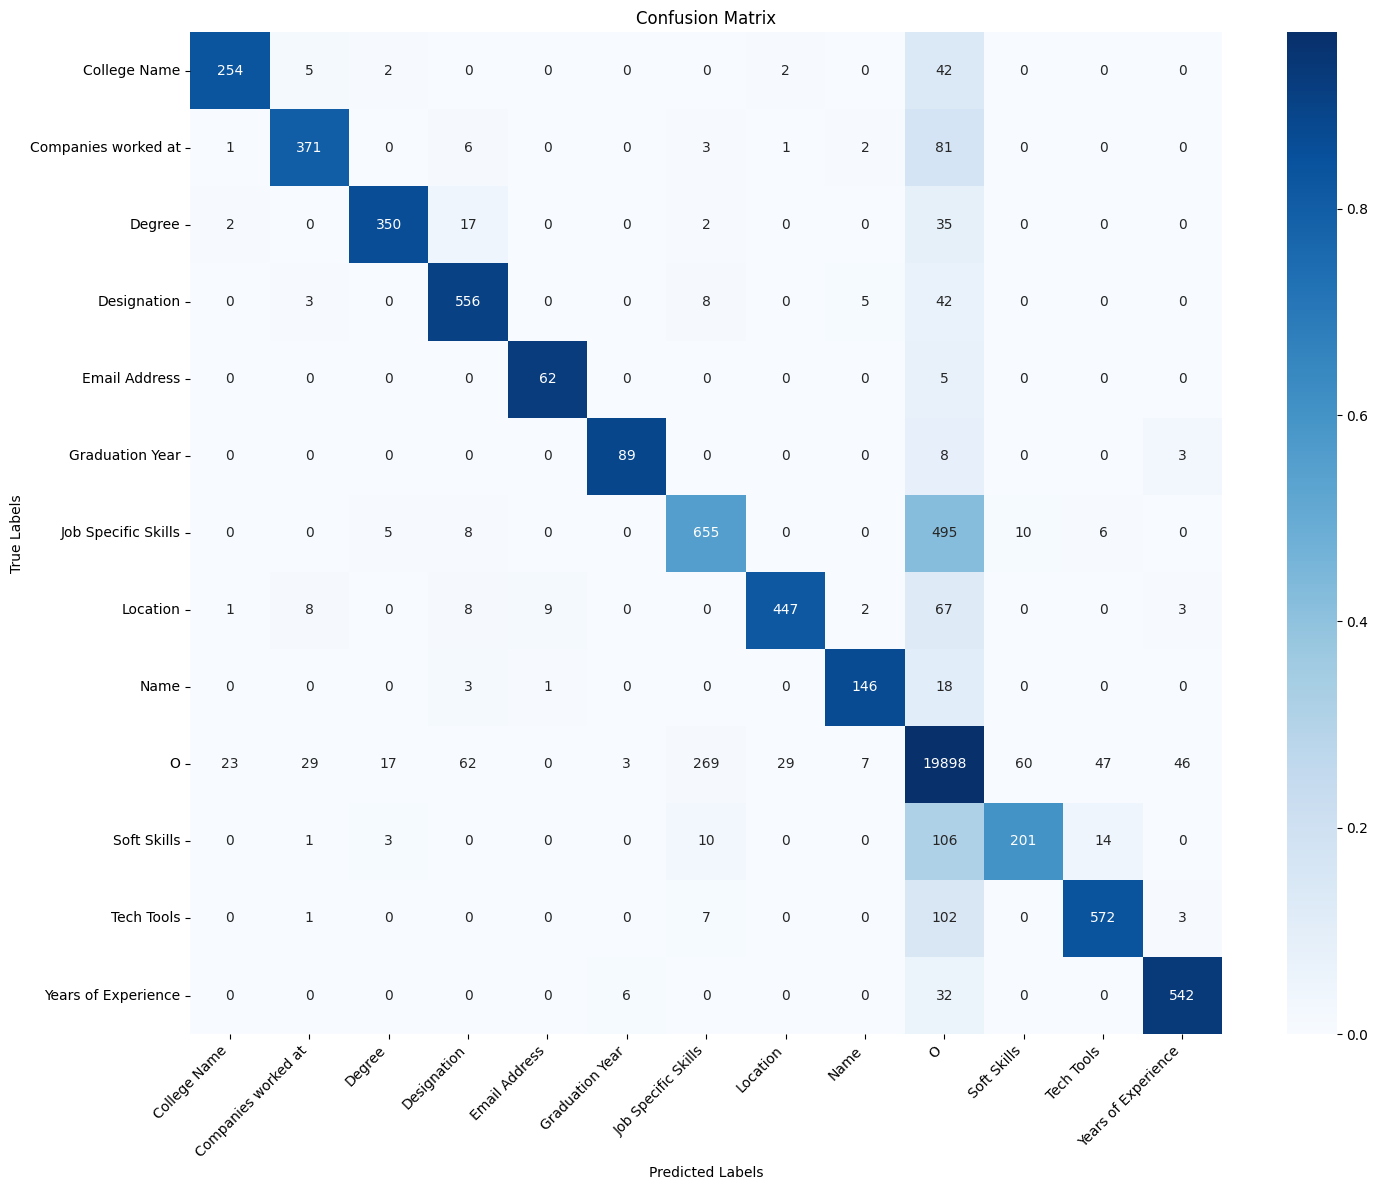

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- First, collect ALL true labels and predictions ---
all_true_labels = []
all_predictions = []

for i in range(len(dataset["test"])):
    for true_label, prediction in zip(true_labels[i], true_predictions[i]):
        all_true_labels.append(true_label)
        all_predictions.append(prediction)

# --- Create confusion matrix ---
labels = sorted(list(set(all_true_labels + all_predictions)))  # Get unique sorted labels
cm = confusion_matrix(all_true_labels, all_predictions, labels=labels)


cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize each row


# --- Plotting ---
plt.figure(figsize=(15, 12))
sns.heatmap(cm_normalized,     annot=cm,  # Show absolute counts as annotations
 fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# --- Compute classification report ---
report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=labels,
    output_dict=True  # Return as dictionary for easier processing
)



# --- Convert to DataFrame and format ---
report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(2)  # Round to 2 decimals
report_df = report_df.drop(columns=['support'])  # Optional: Remove support column

# --- Print with clear formatting ---
print("\nPer-Class Metrics:")
print(report_df.to_markdown(tablefmt="grid", floatfmt=".2f"))


Per-Class Metrics:
+---------------------+-------------+----------+------------+
|                     |   precision |   recall |   f1-score |
+=====================+=============+==========+============+
| College Name        |        0.90 |     0.83 |       0.87 |
+---------------------+-------------+----------+------------+
| Companies worked at |        0.89 |     0.80 |       0.84 |
+---------------------+-------------+----------+------------+
| Degree              |        0.93 |     0.86 |       0.89 |
+---------------------+-------------+----------+------------+
| Designation         |        0.84 |     0.91 |       0.87 |
+---------------------+-------------+----------+------------+
| Email Address       |        0.86 |     0.93 |       0.89 |
+---------------------+-------------+----------+------------+
| Graduation Year     |        0.91 |     0.89 |       0.90 |
+---------------------+-------------+----------+------------+
| Job Specific Skills |        0.69 |     0.56 |  

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import pandas as pd

# --- Compute metrics ---
report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=labels,
    output_dict=True,
    zero_division=0  # Handle classes with no predictions
)

# --- Calculate micro-average metrics ---
micro_precision = precision_score(all_true_labels, all_predictions, average='micro', zero_division=0)
micro_recall = recall_score(all_true_labels, all_predictions, average='micro', zero_division=0)
micro_f1 = f1_score(all_true_labels, all_predictions, average='micro', zero_division=0)

# --- Add micro-average to the report ---
report["micro avg"] = {
    "precision": micro_precision,
    "recall": micro_recall,
    "f1-score": micro_f1,
    "support": report["weighted avg"]["support"]  # Total number of samples
}

# --- Calculate macro-average metrics ---
micro_precision = precision_score(all_true_labels, all_predictions, average='macro', zero_division=0)
micro_recall = recall_score(all_true_labels, all_predictions, average='macro', zero_division=0)
micro_f1 = f1_score(all_true_labels, all_predictions, average='macro', zero_division=0)

# --- Add micro-average to the report ---
report["macro avg"] = {
    "precision": micro_precision,
    "recall": micro_recall,
    "f1-score": micro_f1,
    "support": report["weighted avg"]["support"]  # Total number of samples
}

# --- Remove macro-average (optional) ---
# del report["macro avg"]

# --- Convert to DataFrame and format ---
report_df = pd.DataFrame(report).transpose().round(2)
report_df = report_df.drop(columns=["support"])  # Optional: Remove support column

print("\nPer-Class Metrics with Micro Average:")
print(report_df.to_markdown(tablefmt="grid", floatfmt=".2f"))


Per-Class Metrics with Micro Average:
+---------------------+-------------+----------+------------+
|                     |   precision |   recall |   f1-score |
+=====================+=============+==========+============+
| College Name        |        0.90 |     0.83 |       0.87 |
+---------------------+-------------+----------+------------+
| Companies worked at |        0.89 |     0.80 |       0.84 |
+---------------------+-------------+----------+------------+
| Degree              |        0.93 |     0.86 |       0.89 |
+---------------------+-------------+----------+------------+
| Designation         |        0.84 |     0.91 |       0.87 |
+---------------------+-------------+----------+------------+
| Email Address       |        0.86 |     0.93 |       0.89 |
+---------------------+-------------+----------+------------+
| Graduation Year     |        0.91 |     0.89 |       0.90 |
+---------------------+-------------+----------+------------+
| Job Specific Skills |        

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import pandas as pd



# Remove all 'O'
all_true_labels_without_o = []
all_predictions_without_o = []
for index, label in enumerate(all_true_labels):
  if label!='O' and all_predictions[index] !='O':
    all_true_labels_without_o.append(label)
    all_predictions_without_o.append(all_predictions[index])
labels_without_o = labels.copy()
labels_without_o.remove('O')
# --- Compute metrics ---
report2 = classification_report(
    all_true_labels_without_o,
    all_predictions_without_o,
    target_names=labels_without_o,
    output_dict=True,
    zero_division=0  # Handle classes with no predictions
)




# --- Calculate micro-average metrics ---
micro_precision = precision_score(all_true_labels_without_o, all_predictions_without_o, average='micro', zero_division=0)
micro_recall = recall_score(all_true_labels_without_o, all_predictions_without_o, average='micro', zero_division=0)
micro_f1 = f1_score(all_true_labels_without_o, all_predictions_without_o, average='micro', zero_division=0)

# --- Add micro-average to the report ---
report2["micro avg"] = {
    "precision": micro_precision,
    "recall": micro_recall,
    "f1-score": micro_f1,
    "support": report["weighted avg"]["support"]  # Total number of samples
}

# --- Calculate macro-average metrics ---
# macro_precision = precision_score(all_true_labels_without_o, all_predictions_without_o, average='macro', zero_division=0)
# macro_recall = recall_score(all_true_labels_without_o, all_predictions_without_o, average='macro', zero_division=0)
# macro_f1 = f1_score(all_true_labels_without_o, all_predictions_without_o, average='macro', zero_division=0)

# --- Add macro-average to the report ---
# report["macro avg"] = {
#     "precision": macro_precision,
#     "recall": macro_recall,
#     "f1-score": macro_f1,
#     "support": report["weighted avg"]["support"]  # Total number of samples
# }

# --- Remove macro-average (optional) ---
# del report["macro avg"]

# --- Convert to DataFrame and format ---
report_df = pd.DataFrame(report2).transpose().round(2)
report_df = report_df.drop(columns=["support"])  # Optional: Remove support column

print("\nPer-Class Metrics with Micro Average:")
print(report_df.to_markdown(tablefmt="grid", floatfmt=".2f"))


Per-Class Metrics with Micro Average:
+---------------------+-------------+----------+------------+
|                     |   precision |   recall |   f1-score |
+=====================+=============+==========+============+
| College Name        |        0.99 |     0.94 |       0.96 |
+---------------------+-------------+----------+------------+
| Companies worked at |        0.96 |     0.97 |       0.96 |
+---------------------+-------------+----------+------------+
| Degree              |        0.90 |     0.96 |       0.93 |
+---------------------+-------------+----------+------------+
| Designation         |        0.92 |     0.98 |       0.95 |
+---------------------+-------------+----------+------------+
| Email Address       |        0.87 |     1.00 |       0.93 |
+---------------------+-------------+----------+------------+
| Graduation Year     |        0.94 |     0.97 |       0.95 |
+---------------------+-------------+----------+------------+
| Job Specific Skills |        

In [ ]:
print(tokenized_ds["test"][0]['tokens'])

['Govardhana', 'K', 'Senior', 'Software', 'Engineer', 'Bengaluru,', 'Karnataka,', 'Karnataka', '-', 'Email', 'me', 'on', 'Indeed:', 'indeed.com/r/Govardhana-K/', 'b2de315d95905b68', 'Total', 'IT', 'experience', '5', 'Years', '6', 'Months', 'Cloud', 'Lending', 'Solutions', 'INC', '4', 'Month', '•', 'Salesforce', 'Developer', 'Oracle', '5', 'Years', '2', 'Month', '•', 'Core', 'Java', 'Developer', 'Languages', 'Core', 'Java', ',', 'Go', 'Lang', 'Oracle', 'PL-SQL', 'programming', ',', 'Sales', 'Force', 'Developer', 'with', 'APEX', '.', 'Designations', '&', 'Promotions', 'Willing', 'to', 'relocate:', 'Anywhere', 'WORK', 'EXPERIENCE', 'Senior', 'Software', 'Engineer', 'Cloud', 'Lending', 'Solutions', '-', 'Bangalore,', 'Karnataka', '-', 'January', '2018', 'to', 'Present', 'Present', 'Senior', 'Consultant', 'Oracle', '-', 'Bangalore,', 'Karnataka', '-', 'November', '2016', 'to', 'December', '2017', 'Staff', 'Consultant', 'Oracle', '-', 'Bangalore,', 'Karnataka', '-', 'January', '2014', 'to', 